In [31]:
import pandas as pd
from statsmodels.tsa.seasonal import STL
import numpy as np
import matplotlib.pyplot as plt
import random
from typing import List
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.ar_model import AutoReg


def gerar_cor_aleatoria():
    return "#%06x" % random.randint(0, 0xFFFFFF)


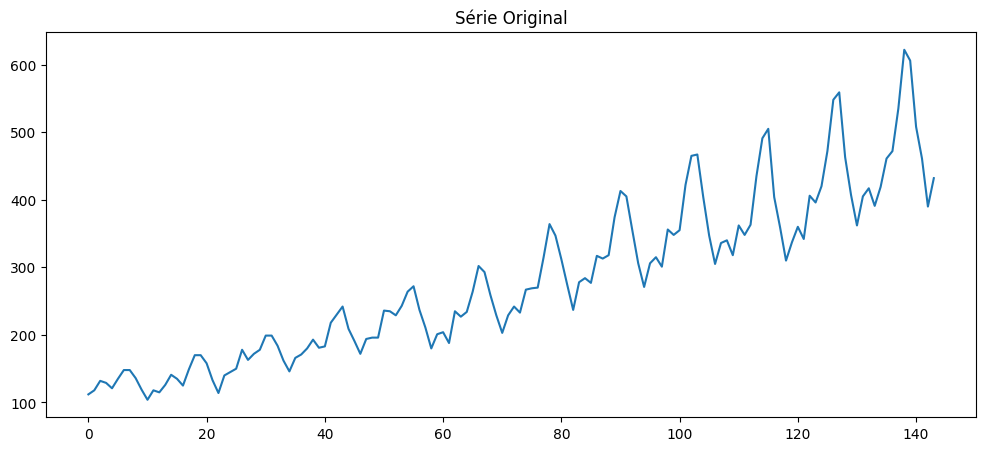

In [32]:
df = pd.read_csv('AirPassengers.csv', parse_dates=['Month'])
serie = df['#Passengers']

plt.figure(figsize=(12,5))
plt.plot(serie)
plt.title('Série Original')
plt.show()



ADF - Série Original
ADF Statistic: 0.8154, p-value: 0.9919

KPSS - Série Original
KPSS Statistic: 1.6513, p-value: 0.0100
KPSS Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}

ADF - Série Diferenciada
ADF Statistic: -2.8293, p-value: 0.0542

KPSS - Série Diferenciada
KPSS Statistic: 0.0239, p-value: 0.1000
KPSS Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}


C:\Users\igorpereira-ieg\AppData\Local\Temp\ipykernel_12012\1833801709.py:12: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, _, kpss_crit = kpss(s, regression='c', nlags='auto')
C:\Users\igorpereira-ieg\AppData\Local\Temp\ipykernel_12012\1833801709.py:22: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat2, kpss_p2, _, kpss_crit2 = kpss(s_diff, regression='c', nlags='auto')


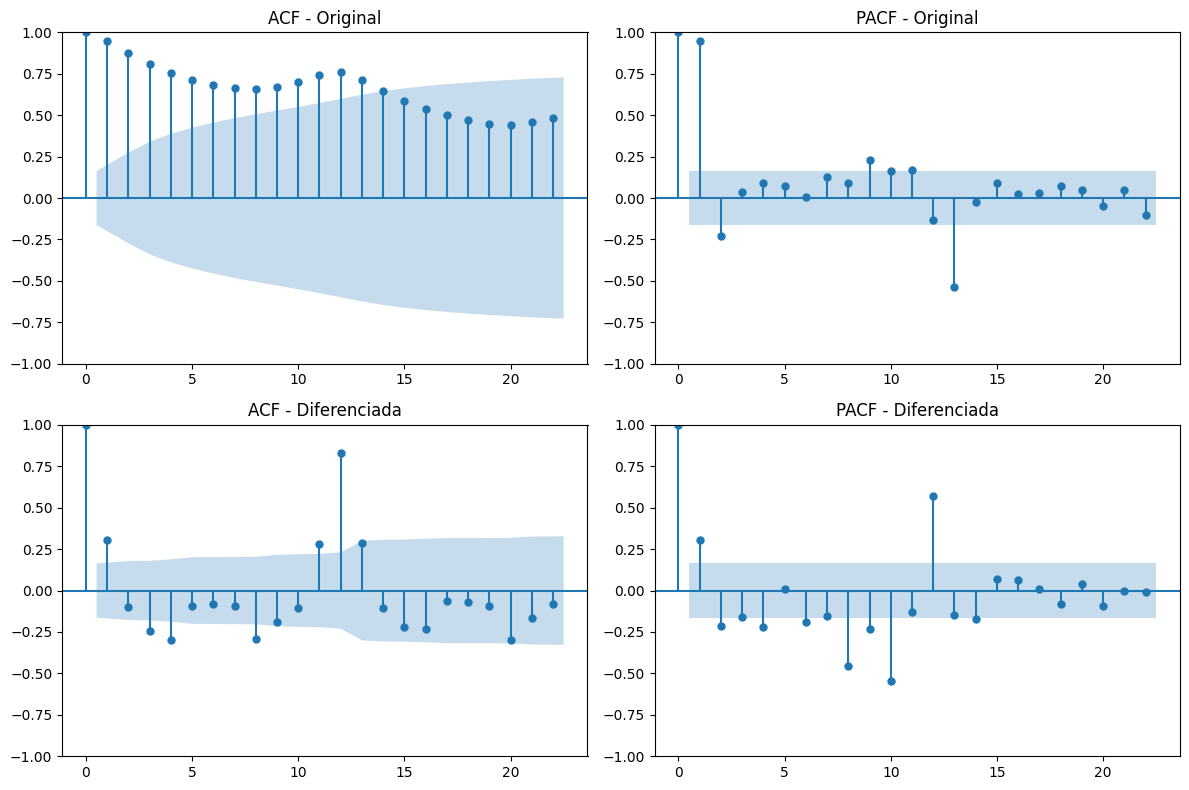

In [33]:
def aplicar_testes(serie):
    from statsmodels.tsa.stattools import adfuller, kpss
    import matplotlib.pyplot as plt
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

    s = serie.dropna()
    print('ADF - Série Original')
    adf_res = adfuller(s)
    print(f"ADF Statistic: {adf_res[0]:.4f}, p-value: {adf_res[1]:.4f}")

    print('\nKPSS - Série Original')
    kpss_stat, kpss_p, _, kpss_crit = kpss(s, regression='c', nlags='auto')
    print(f"KPSS Statistic: {kpss_stat:.4f}, p-value: {kpss_p:.4f}")
    print('KPSS Critical Values:', kpss_crit)

    s_diff = serie.diff().dropna()
    print('\nADF - Série Diferenciada')
    adf_res2 = adfuller(s_diff)
    print(f"ADF Statistic: {adf_res2[0]:.4f}, p-value: {adf_res2[1]:.4f}")

    print('\nKPSS - Série Diferenciada')
    kpss_stat2, kpss_p2, _, kpss_crit2 = kpss(s_diff, regression='c', nlags='auto')
    print(f"KPSS Statistic: {kpss_stat2:.4f}, p-value: {kpss_p2:.4f}")
    print('KPSS Critical Values:', kpss_crit2)

    fig, ax = plt.subplots(2,2, figsize=(12,8))
    plot_acf(s, ax=ax[0,0])
    ax[0,0].set_title('ACF - Original')
    plot_pacf(s, ax=ax[0,1], method='ywm')
    ax[0,1].set_title('PACF - Original')

    plot_acf(s_diff, ax=ax[1,0])
    ax[1,0].set_title('ACF - Diferenciada')
    plot_pacf(s_diff, ax=ax[1,1], method='ywm')
    ax[1,1].set_title('PACF - Diferenciada')

    plt.tight_layout()
    plt.show()

# Executa os testes na série carregada
aplicar_testes(serie)


In [34]:
resultado = adfuller(serie)

print('ADF Statistic:', resultado[0])
print('p-value:', resultado[1])

ADF Statistic: 0.8153688792060482
p-value: 0.991880243437641


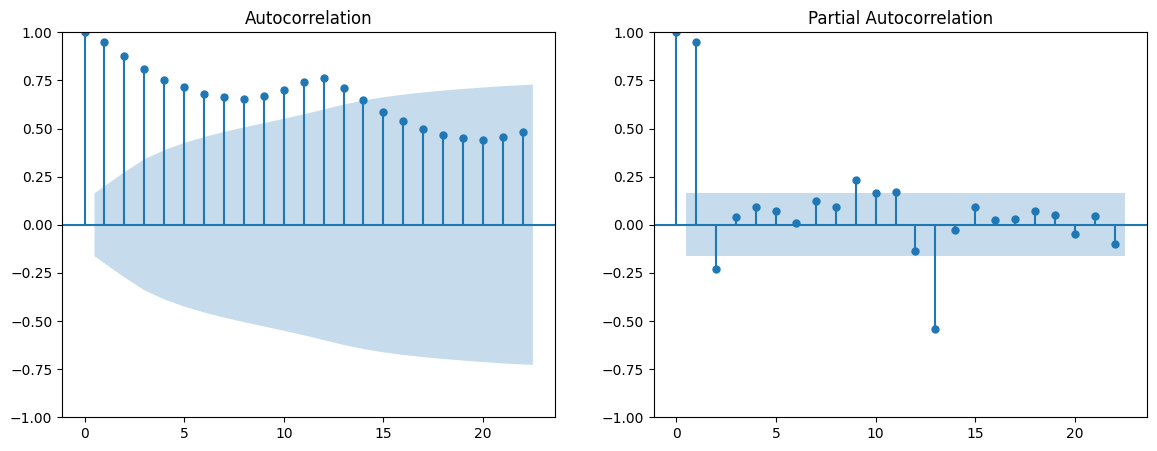

In [35]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

plot_acf(serie, ax=ax[0])
plot_pacf(serie, ax=ax[1])

plt.show()

In [36]:
serie_diff = serie.diff().dropna()

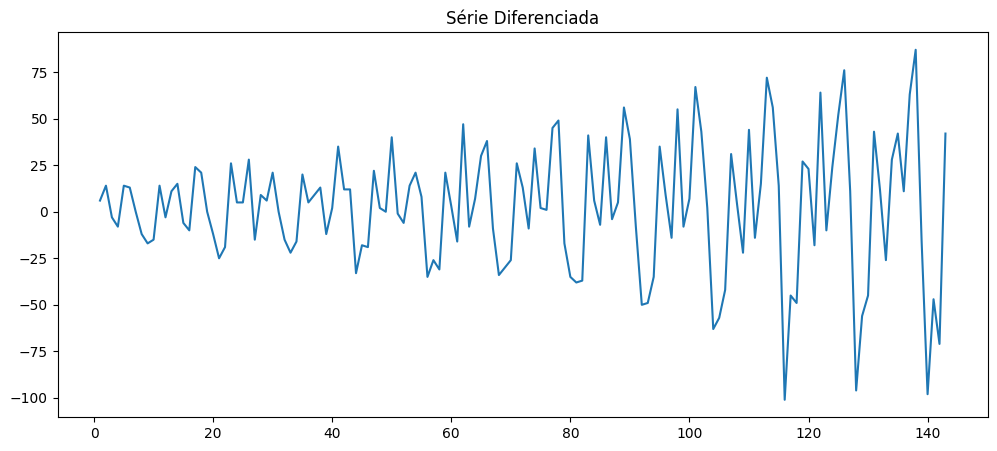

In [37]:
plt.figure(figsize=(12,5))
plt.plot(serie_diff)
plt.title('Série Diferenciada')
plt.show()

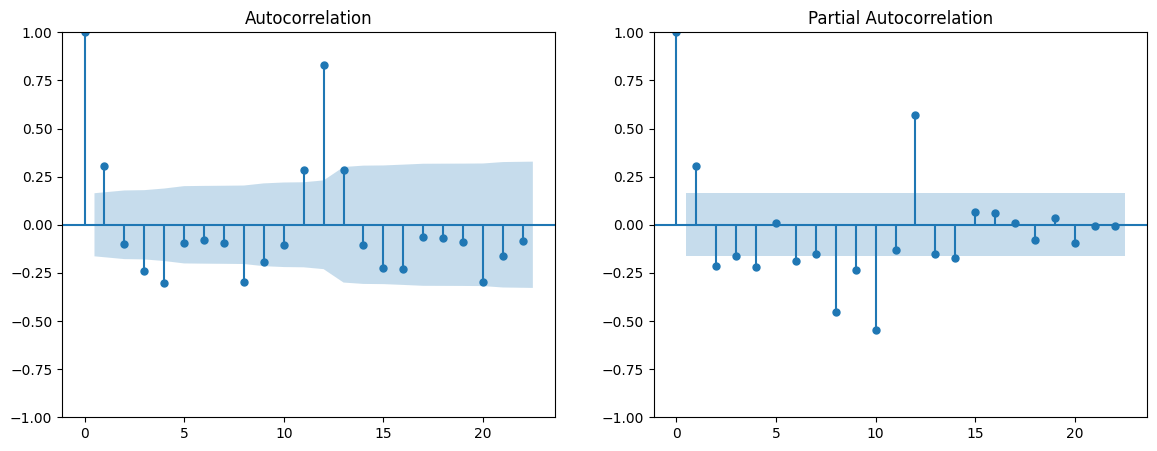

In [38]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

plot_acf(serie_diff, ax=ax[0])
plot_pacf(serie_diff, ax=ax[1])

plt.show()

In [39]:
resultado = adfuller(serie_diff)

print('ADF Statistic:', resultado[0])
print('p-value:', resultado[1])

ADF Statistic: -2.8292668241699994
p-value: 0.0542132902838255


In [40]:
def gerando_media_historica(dados: List):
    serie = pd.Series(dados, dtype=float)
    previsao = [np.nan]
    for t in range(1, len(serie)):
        previsao.append(serie.iloc[:t].mean())
    previsao = pd.Series(previsao, index=serie.index)
    
    erro = mean_absolute_error(serie[1:], previsao[1:])
    
    plt.figure(figsize=(8,5))
    plt.plot(serie, label="Série Original", marker='o')
    plt.plot(previsao, label=f"Média Histórica One-step (MAE: {erro:.2f})", color='red', linestyle='--')
    plt.legend()
    plt.title("Base Model: Média Histórica")
    plt.show()
    
    print(f"MAE Média Histórica: {erro:.4f}")
    return previsao, erro


In [41]:
def gerando_media_acumulada(dados: List):
    serie = pd.Series(dados)
    
    # expand().mean() calcula a média acumulada. shift(1) move para ser a previsão do próximo passo.
    previsao = serie.expanding().mean().shift(1)
    
    valid_idx = previsao.dropna().index
    erro = mean_absolute_error(serie[valid_idx], previsao[valid_idx])
    
    plt.figure(figsize=(8,5))
    plt.plot(serie, label="Série Original", marker='o')
    plt.plot(previsao, label=f"Média Acumulada (MAE: {erro:.2f})", color='green', linestyle='--')
    plt.legend()
    plt.title("Base Model: Média Acumulada")
    plt.show()
    
    print(f"MAE Média Acumulada: {erro:.4f}")
    return previsao.iloc[-1], erro  # Retorna a última média calculada e o MAE


In [42]:
def gerando_media_movel(dados: List):
    serie = pd.Series(dados)
    tamanho_serie = len(serie)

    sma_detalhado = pd.DataFrame({'Dados': serie})
    resultado = pd.DataFrame()

    max_plot = min(36, tamanho_serie - 1)  # plotar apenas janelas até esse tamanho para evitar poluição

    plt.figure(figsize=(12,6))
    plt.plot(serie, label="Série Original", linewidth=2, marker='o')

    erro_top = float('inf')
    k = None

    for janela in range(1, tamanho_serie):
        rolling_mean = serie.rolling(window=janela).mean().shift(1)

        medias_validas = rolling_mean.dropna()
        serie_adaptada = serie[medias_validas.index]

        if len(medias_validas) > 0:
            erro = mean_absolute_error(medias_validas, serie_adaptada)

            if erro < erro_top:
                erro_top = erro
                k = janela

            nova_linha = pd.DataFrame({'Janela': [janela], 'MAE': [erro]})
            resultado = pd.concat([resultado, nova_linha], ignore_index=True)

            sma_detalhado[f'sma_{janela}'] = rolling_mean

            # Plotar apenas um subconjunto (janelas pequenas) para evitar poluição visual
            if janela <= max_plot:
                plt.plot(medias_validas.index, medias_validas.values,
                         label=f"SMA Janela {janela}", color=gerar_cor_aleatoria(), alpha=0.7, linewidth=1)

    # Destacar a melhor janela encontrada (mesmo que seja maior que max_plot)
    if k is not None:
        best_series = serie.rolling(window=k).mean().shift(1)
        plt.plot(best_series.index, best_series.values, label=f"Melhor SMA (janela {k})", color='black', linewidth=2.5)

    # Ajustar limites y para evitar que linhas saiam muito da tela
    y_min = serie.min() - serie.std() * 0.5
    y_max = serie.max() + serie.std() * 0.5
    plt.ylim(y_min, y_max)

    plt.legend(ncol=2, fontsize='small')
    plt.title("Base Model: Média Móvel Simples (SMA)")
    plt.tight_layout()
    plt.show()

    resultado = resultado.sort_values('MAE')
    print("Comparação de janelas SMA:")
    print(resultado)

    print(f"Melhor janela SMA: {k} com MAE {erro_top:.4f}")
    if tamanho_serie - 1 > max_plot:
        print(f"(Plotei apenas janelas até {max_plot} para clareza; total janelas avaliadas: {tamanho_serie-1})")
    return k, erro_top, resultado


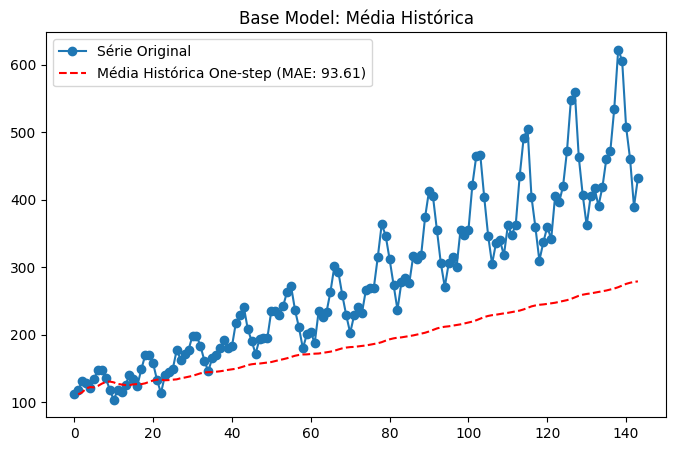

MAE Média Histórica: 93.6114


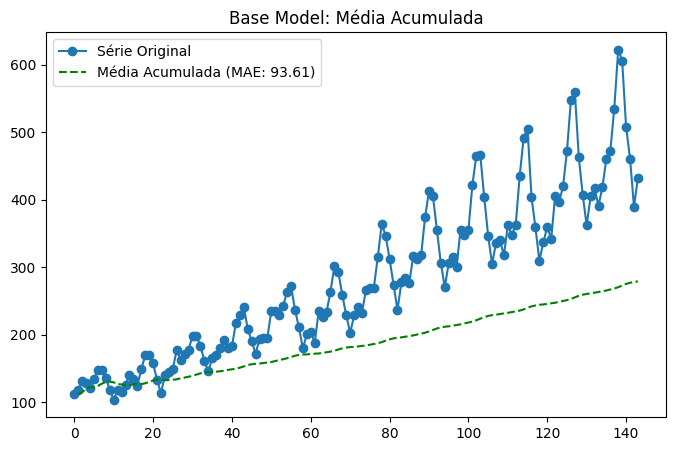

MAE Média Acumulada: 93.6114


C:\Users\igorpereira-ieg\AppData\Local\Temp\ipykernel_12012\492362742.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sma_detalhado[f'sma_{janela}'] = rolling_mean
C:\Users\igorpereira-ieg\AppData\Local\Temp\ipykernel_12012\492362742.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sma_detalhado[f'sma_{janela}'] = rolling_mean
C:\Users\igorpereira-ieg\AppData\Local\Temp\ipykernel_12012\492362742.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, w

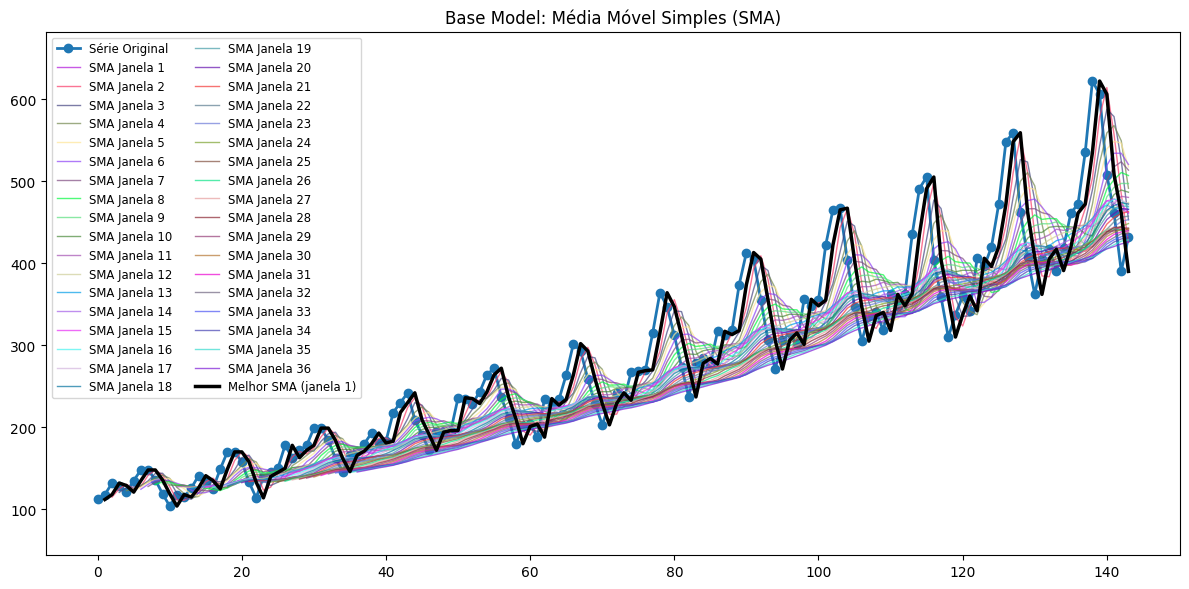

Comparação de janelas SMA:
     Janela         MAE
0         1   25.860140
1         2   31.978873
12       13   34.354081
13       14   34.908791
11       12   35.248106
..      ...         ...
133     134  213.553731
134     135  221.218930
137     138  224.631643
135     136  225.556066
136     137  229.623566

[143 rows x 2 columns]
Melhor janela SMA: 1 com MAE 25.8601
(Plotei apenas janelas até 36 para clareza; total janelas avaliadas: 143)

===== Resumo de MAEs =====
Média Histórica MAE: 93.6114
Média Acumulada MAE: 93.6114
Melhor SMA: janela 1 com MAE 25.8601

Top 5 janelas SMA:
    Janela        MAE
0        1  25.860140
1        2  31.978873
12      13  34.354081
13      14  34.908791
11      12  35.248106


In [43]:
# Resumo: executar cada base model e mostrar MAE
previsao_hist, mae_hist = gerando_media_historica(serie.tolist())
last_acum, mae_acum = gerando_media_acumulada(serie.tolist())
k_best, mae_sma, resultado_sma = gerando_media_movel(serie.tolist())

print('\n===== Resumo de MAEs =====')
print(f"Média Histórica MAE: {mae_hist:.4f}")
print(f"Média Acumulada MAE: {mae_acum:.4f}")
print(f"Melhor SMA: janela {k_best} com MAE {mae_sma:.4f}")

print('\nTop 5 janelas SMA:')
print(resultado_sma.sort_values('MAE').head())
